# EDA - ETAI

## Data dictionary

One row = one defendant, with their demographics and criminal history at the time of screening, COMPAS's own risk score for them, and whether they were actually rearrested within two years.

| column | type | description | notable values |
|--------|------|--------------|------------------|
| `id` | identifier | internal record id | not a model feature |
| `sex` | categorical | defendant's sex | `Male`, `Female` |
| `age` | numeric | defendant's age (years) at screening | |
| `age_cat` | categorical | age bucket | `Less than 25`, `25 - 45`, `Greater than 45` |
| `race` | categorical | defendant's race, as recorded | excluded from model features- kept aside only to audit fairness afterward |
| `juv_fel_count` | numeric | number of prior juvenile felony offenses | |
| `juv_misd_count` | numeric | number of prior juvenile misdemeanor offenses | |
| `juv_other_count` | numeric | number of other prior juvenile offenses | |
| `juvenile_total` | numeric | total juvenile offenses | |
| `priors_count` | numeric | number of prior adult offenses | |
| `prior_offenses` | numeric | number of prior offenses | |
| `age_in_months` | numeric | age expressed in months |  |
| `c_charge_degree` | categorical | degree of the current charge | `F` (felony), `M` (misdemeanor) |
| `decile_score` | numeric | COMPAS's own risk score | 1 (lowest) to 10 (highest); excluded from model features, used only for comparison |
| `score_text` | categorical | COMPAS's own risk category | `Low`, `Medium`, `High`; excluded from model features |
| `two_year_recid` | binary | **our target** - was this person rearrested within two years? | `0` = no, `1` = yes |


## Start of EDA

In [6]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

BLUE = "#5EDDF3"
ORANGE = "#F78441"
GRAY = "#8E9196"
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["font.size"] = 10.5

RAW_PATH = r"C:\Users\diogo\Desktop\NOVA IMS\IA\Labs\ETAI-Pipeline\data\compas_two_year_recidivism.csv"
df_raw = pd.read_csv(RAW_PATH)
print(df_raw.shape)
df_raw.head(30)

(7286, 16)


,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
0,1,Low,0.0,0,1.0,Male,25 - 45,8423,F,0,0.0,324.0,African-American,0.0,27.0,2
1,0,High,3.0,0,0.0,Male,Less than 25,4137,M,1,0.0,276.0,Caucasian,3.0,23.0,8
2,0,Low,2.0,0,0.0,male,25 - 45,5064,F,1,0.0,336.0,Caucasian,2.0,28.0,2
3,0,High,2.0,0,0.0,female,Less than 25,56,F,0,NaN,252.0,African-American,2.0,21.0,8
4,0,Low,1.0,0,0.0,Male,25 - 45,9369,M,0,0.0,372.0,African-American,1.0,31.0,4
5,0,Low,NaN,0,0.0,Female,Greater than 45,7663,F,0,0.0,612.0,Caucasian,NaN,51.0,1
6,1,High,18.0,2,3.0,MALE,25 - 45,967,F,1,0.0,324.0,African-American,18.0,27.0,9
7,0,High,1.0,0,0.0,Male,Less than 25,718,F,1,0.0,240.0,African-American,1.0,20.0,10
8,0,Low,1.0,0,0.0,Male,25 - 45,10296,F,0,0.0,480.0,?,1.0,40.0,3
9,0,High,16.0,0,0.0,Male,25 - 45,3086,F,1,0.0,372.0,Hispanic,16.0,31.0,10


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7286 entries, 0 to 7285
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   juv_other_count  7286 non-null   int64  
 1   score_text       7286 non-null   object 
 2   priors_count     6866 non-null   object 
 3   juv_misd_count   7286 non-null   int64  
 4   juvenile_total   7286 non-null   float64
 5   sex              7226 non-null   object 
 6   age_cat          7286 non-null   object 
 7   id               7286 non-null   int64  
 8   c_charge_degree  7053 non-null   object 
 9   two_year_recid   7286 non-null   int64  
 10  juv_fel_count    7069 non-null   float64
 11  age_in_months    7140 non-null   float64
 12  race             7286 non-null   object 
 13  prior_offenses   6866 non-null   object 
 14  age              7140 non-null   float64
 15  decile_score     7286 non-null   int64  
dtypes: float64(4), int64(5), object(7)
memory usage: 910.9+ KB


In [8]:
object_looking_numeric = [c for c in ["priors_count", "prior_offenses"] if not pd.api.types.is_numeric_dtype(df_raw[c])]
print("Columns that SHOULD be numeric but loaded as text:", object_looking_numeric)
for c in object_looking_numeric:
    non_numeric_values = df_raw[c][pd.to_numeric(df_raw[c], errors="coerce").isna() & df_raw[c].notna()]
    print(f"  {c}: non-numeric tokens found -> {sorted(non_numeric_values.unique())}")

Columns that SHOULD be numeric but loaded as text: ['priors_count', 'prior_offenses']
  priors_count: non-numeric tokens found -> ['-']
  prior_offenses: non-numeric tokens found -> ['-']


From this we can see that `priors_count` and `prior_offenses` read in as text, not numbers - a single non-numeric token anywhere in a column is enough for pandas to type the whole thing as `object`. That's often the *first* sign of a placeholder value hiding in a numeric column.

In [9]:
#Checking the percentage of missing values for each column:
round(df_raw.isna().sum()/len(df_raw)*100,2)

juv_other_count    0.00
score_text         0.00
priors_count       5.76
juv_misd_count     0.00
juvenile_total     0.00
sex                0.82
age_cat            0.00
id                 0.00
c_charge_degree    3.20
two_year_recid     0.00
juv_fel_count      2.98
age_in_months      2.00
race               0.00
prior_offenses     5.76
age                2.00
decile_score       0.00
dtype: float64

In [10]:
#Checking basic duplicated data
df_raw.duplicated().sum()

np.int64(72)

From the percentage of missing values we see that no column has a huge percentage of values missing. But we should be looking for the ones with some missing values in the future!

From the duplicated data we see that we have 72 duplicated columns that we will also adress in the future

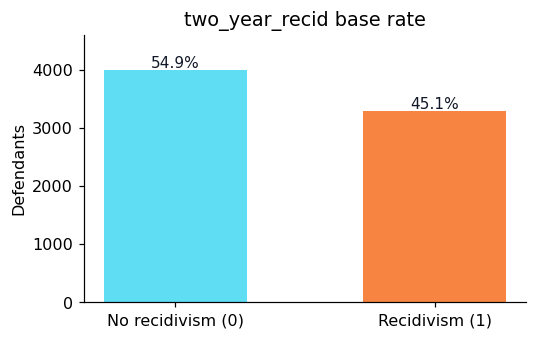

{0: 3999, 1: 3287}


In [11]:
counts = df_raw["two_year_recid"].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(["No recidivism (0)", "Recidivism (1)"], counts.values, color=[BLUE, ORANGE], width=0.55)
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 40, f"{p}%", ha="center", fontsize=10, color="#111827")
ax.set_ylabel("Defendants")
ax.set_title("two_year_recid base rate")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

print(counts.to_dict())

Pretty balanced dataset. So no big worries in this part!

## Adressing the missing values

More than understanding **how many** missing values we are dealing with, we need to understand **what kind** of missing values we are dealing with! For that, we can use a missing-value indicator.

A missing-value indicator is just another binary column. If it has **no real relationship** to anything else you can observe, the data is probably missing completely at random (MCAR) - safe to impute simply.


Whether this indicator is missing at random has a precise, standard answer with three cases, and which one holds decides whether a fill can be trusted:

 - **MCAR, missing completely at random**: whether a cell is missing has nothing to do with anything -- not the hidden value, not any other column. The missing values are a random sample, and a simple fill costs only precision.
  - **MAR, missing at random**: whether a cell is missing depends on other, observed columns, but not on the hidden value itself once those are accounted for. A fill informed by those columns is defensible.
  - **MNAR, missing not at random**: whether a cell is missing depends on the hidden value itself, or on something never recorded. No fill is safe on its own, and an explicit "was missing" flag often beats erasing the pattern.
You never see the hidden values, so MCAR cannot be proven outright. What you can do is test each missingness flag against the columns you do observe: if a flag is tied to any of them, those missing values are not completely at random, and the fill has to answer for that.

The target is left out of these tests on purpose. Deciding how to clean the data from the target lets the label steer preprocessing -- a leak, one step earlier than fitting a model to it. Missingness is diagnosed from the features only.

The tool: for each column with missing values, cross-tabulate its missingness indicator against every other categorical column, run a chi-square test, and report the **effect size (Cramér's V)** alongside the p-value. At this sample size (~7,000 rows), p-values get tiny for even trivial associations - Cramér's V is what actually tells you whether the association is *big enough to matter* (roughly: well under 0.1 is weak/scattered, the closer you get to 1, the stronger the association). 

In [12]:
def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    """Bias-corrected Cramer's V effect size for a chi-square test of association."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return float(np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1)))


def test_missingness_mechanism(df: pd.DataFrame, target_col: str, candidate_predictors: list) -> pd.DataFrame:
    """
    For `target_col`'s missing-value indicator, test association against each
    column in `candidate_predictors` via chi-square + Cramer's V.
    Returns one row per predictor, sorted by association strength (strongest first).
    """
    indicator = df[target_col].isna()
    rows = []
    for predictor in candidate_predictors:
        if predictor == target_col:
            continue
        sub = pd.DataFrame({"missing": indicator, "predictor": df[predictor]}).dropna(subset=["predictor"])
        if sub["predictor"].nunique() < 2 or sub["missing"].nunique() < 2:
            continue
        table = pd.crosstab(sub["missing"], sub["predictor"])
        chi2, p, _, _ = chi2_contingency(table)
        v = cramers_v(table)
        rows.append({"predictor": predictor, "cramers_v": round(v, 3), "p_value": p, "n": len(sub)})
    result = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
    return result


def verdict_from_max_v(max_v: float) -> str:
    if max_v >= 0.2:
        return "MAR / MNAR (possible pattern)"
    elif max_v >= 0.1:
        return "borderline -- worth a closer look"
    else:
        return "MCAR (scattered, no pattern found)"


In [13]:
candidate_predictors = ["sex", "race", "age_cat", "c_charge_degree", "score_text"]
raw_missing_cols = [c for c in ["juv_fel_count", "age", "priors_count", "c_charge_degree"]
                     if df_raw[c].isna().any()]

first_pass_results = {}
for col in raw_missing_cols:
    preds = [p for p in candidate_predictors if p != col]
    first_pass_results[col] = test_missingness_mechanism(df_raw, col, preds)
    print(f"=== {col} (n missing = {df_raw[col].isna().sum()}) ===")
    print(first_pass_results[col])
    print()

=== juv_fel_count (n missing = 217) ===
         predictor  cramers_v   p_value     n
0             race      0.043  0.021557  7286
1       score_text      0.027  0.095966  7286
2          age_cat      0.016  0.138351  7286
3              sex      0.000  0.462852  7226
4  c_charge_degree      0.000  0.817269  7053

=== age (n missing = 146) ===
         predictor  cramers_v   p_value     n
0  c_charge_degree      0.043  0.002708  7053
1       score_text      0.022  0.178644  7286
2             race      0.016  0.325899  7286
3              sex      0.000  0.595249  7226
4          age_cat      0.000  0.867306  7286

=== priors_count (n missing = 420) ===
         predictor  cramers_v        p_value     n
0          age_cat      0.395  2.112272e-247  7286
1       score_text      0.084   6.533206e-10  7286
2             race      0.055   1.385716e-03  7286
3  c_charge_degree      0.040   5.703946e-03  7053
4              sex      0.000   7.477236e-01  7226

=== c_charge_degree (n missing

In [14]:
first_pass_verdicts = pd.DataFrame([
    {
        "column": col,
        "strongest_predictor": res.iloc[0]["predictor"] if len(res) else None,
        "max_cramers_v": res.iloc[0]["cramers_v"] if len(res) else None,
        "verdict": verdict_from_max_v(res.iloc[0]["cramers_v"] if len(res) else 0.0),
    }
    for col, res in first_pass_results.items()
])
first_pass_verdicts

,column,strongest_predictor,max_cramers_v,verdict
0,juv_fel_count,race,0.043,"MCAR (scattered, no pattern found)"
1,age,c_charge_degree,0.043,"MCAR (scattered, no pattern found)"
2,priors_count,age_cat,0.395,MAR / MNAR (possible pattern)
3,c_charge_degree,age_cat,0.349,MAR / MNAR (possible pattern)


**Verdict, first pass**:

- `juv_fel_count`, `age` - every association is weak (Cramér's V well under 0.1). No column in the data explains *who* is missing here. Reads as **MCAR** - safe to impute with something simple, no indicator flag needed.
- `priors_count` - strongly associated with `age_cat` (older defendants have spottier digitized records). Reads as **MNAR**: the *reason* it's missing depends on an observed variable, not chance.
- `c_charge_degree` - strongly associated with `age_cat` too (younger defendants' paperwork logged less consistently). Also **MNAR**.

Two very different verdicts, from the same test. A blanket "just drop rows with missing values" treats all four of these the same way, which is defensible for the first two and actively loses signal for the last two.

Worth sitting with the borderline band (`verdict_from_max_v`'s 0.1–0.2 zone) for a second: none of today's four columns land there, but it's not an edge case to design away - a real dataset will eventually hand you a Cramér's V of 0.14 and no clean answer. The honest move in that zone isn't to round up to MNAR or down to MCAR by feel; it's to treat the *indicator* itself, once flagged, as worth a quick sanity check against a second, independent predictor before committing - the same instinct as checking two things agree (Technique 3, below) rather than trusting one signal alone.

## Adressing Invalid Values

`.isna()` only catches values that are *already* `NaN`. It says nothing about values that are technically present but **impossible** - an age of 5, a COMPAS decile score of 15 (the scale tops out at 10). Those need a rule that knows something about what the column actually means, not a generic missing-value scan.

In [15]:
def domain_rule_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    # age: implausible if outside a plausible adult defendant range
    age_num = pd.to_numeric(df["age"], errors="coerce")
    bad_age = df["age"].notna() & ~age_num.between(18, 100)
    rows.append({"column": "age", "rule": "18 <= age <= 100", "violations": int(bad_age.sum()),
                 "examples": sorted(age_num[bad_age].unique().tolist())[:6]})

    # decile_score: COMPAS's own scale is documented as 1-10
    bad_decile = ~df["decile_score"].between(1, 10)
    rows.append({"column": "decile_score", "rule": "1 <= decile_score <= 10", "violations": int(bad_decile.sum()),
                 "examples": sorted(df.loc[bad_decile, "decile_score"].unique().tolist())})

    # juv_fel_count: a count can't be negative
    jfc_num = pd.to_numeric(df["juv_fel_count"], errors="coerce")
    bad_jfc = df["juv_fel_count"].notna() & (jfc_num < 0)
    rows.append({"column": "juv_fel_count", "rule": "juv_fel_count >= 0", "violations": int(bad_jfc.sum()),
                 "examples": sorted(jfc_num[bad_jfc].unique().tolist())})

    # priors_count: after coercing placeholder tokens, a count can't be absurdly large or negative
    pc_num = pd.to_numeric(df["priors_count"].replace({"-": np.nan}), errors="coerce")
    bad_pc = pc_num.notna() & ((pc_num < 0) | (pc_num > 60))
    rows.append({"column": "priors_count", "rule": "0 <= priors_count <= 60", "violations": int(bad_pc.sum()),
                 "examples": sorted(pc_num[bad_pc].unique().tolist())})

    return pd.DataFrame(rows)

domain_rule_report(df_raw)

,column,rule,violations,examples
0,age,18 <= age <= 100,9,"[-3.0, 5.0]"
1,decile_score,1 <= decile_score <= 10,6,"[0, 15, 23]"
2,juv_fel_count,juv_fel_count >= 0,5,[-1.0]
3,priors_count,0 <= priors_count <= 60,6,"[250.0, 500.0]"


Four real violations, none of them a `NaN` -- an age of `-3`, a decile score of `23` on a scale that stops at 10, a juvenile-felony count of `-1`, a priors count of `250` or `500`. All four get converted to `NaN` before anything downstream treats them as legitimate data - "impossible but not missing" is still missing.

`priors_count` and `prior_offenses` type as text because of tokens like `-`. `race` and `sex` have the same problem with `?`, `n/a`, and similar stand-ins - none of these are legitimate categories, but none of them show up in `.isna()` either.

In [16]:
placeholder_tokens = {"-", "?", "n/a", "N/A", "na", "NA", ""}

def find_placeholder_rows(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().isin(placeholder_tokens)

for col in ["race", "sex", "priors_count", "prior_offenses"]:
    mask = find_placeholder_rows(df_raw[col])
    tokens_found = sorted(df_raw.loc[mask, col].astype(str).str.strip().unique().tolist())
    print(f"{col}: {mask.sum()} placeholder rows -> tokens {tokens_found}")

race: 144 placeholder rows -> tokens ['-', '?']
sex: 49 placeholder rows -> tokens ['?']
priors_count: 81 placeholder rows -> tokens ['-']
prior_offenses: 81 placeholder rows -> tokens ['-']


Once those tokens are converted to real `NaN`, three more columns have missing data that `.isna()` didn't show on the raw file. Worth re-running the exact same mechanism test on them - no reason to trust them less than the first four.

In [17]:
df_stage1 = df_raw.copy()
for col in ["race", "sex", "priors_count", "prior_offenses"]:
    mask = find_placeholder_rows(df_stage1[col])
    df_stage1.loc[mask, col] = np.nan


age_num = pd.to_numeric(df_stage1["age"], errors="coerce")
df_stage1.loc[df_stage1["age"].notna() & ~age_num.between(18, 100), "age"] = np.nan
df_stage1.loc[~df_stage1["decile_score"].between(1, 10), "decile_score"] = np.nan
jfc_num = pd.to_numeric(df_stage1["juv_fel_count"], errors="coerce")
df_stage1.loc[df_stage1["juv_fel_count"].notna() & (jfc_num < 0), "juv_fel_count"] = np.nan
df_stage1["priors_count"] = pd.to_numeric(df_stage1["priors_count"], errors="coerce")
df_stage1["prior_offenses"] = pd.to_numeric(df_stage1["prior_offenses"], errors="coerce")
pc_num = df_stage1["priors_count"]
df_stage1.loc[pc_num.notna() & ((pc_num < 0) | (pc_num > 60)), "priors_count"] = np.nan

second_pass_results = {}
for col in ["race", "sex"]:
    preds = [p for p in candidate_predictors if p != col]
    second_pass_results[col] = test_missingness_mechanism(df_stage1, col, preds)
    print(f"=== {col} (n missing after placeholder conversion = {df_stage1[col].isna().sum()}) ===")
    print(second_pass_results[col])
    print()

=== race (n missing after placeholder conversion = 144) ===
         predictor  cramers_v   p_value     n
0              sex        0.0  0.717151  7177
1          age_cat        0.0  0.561140  7286
2  c_charge_degree        0.0  0.748426  7053
3       score_text        0.0  0.974821  7286

=== sex (n missing after placeholder conversion = 109) ===
         predictor  cramers_v   p_value     n
0             race        0.0  0.936157  7142
1          age_cat        0.0  0.654788  7286
2  c_charge_degree        0.0  0.430220  7053
3       score_text        0.0  0.913379  7286



**Verdict, second pass:** `race` and `sex`'s newly-revealed missingness is weak everywhere too - another **MCAR** story, consistent with placeholder tokens being a generic data-entry accident rather than tied to any one group. Good news for the fairness angle specifically: if `race`'s missingness *had* been tangled up with another demographic column, that would be its own small red flag worth a second look.

## Columns regularization

In [20]:
def peek_variants(series: pd.Series, n=12):
    return series.value_counts(dropna=False).head(n)


# Selecionar todas as colunas não numéricas
non_numeric_cols = df_raw.select_dtypes(exclude="number").columns

print("Colunas não numéricas:")
print(list(non_numeric_cols))
print()

# Mostrar os valores mais frequentes de cada coluna
for col in non_numeric_cols:
    print(f"{col}, raw:")
    print(peek_variants(df_raw[col]))
    print()

Colunas não numéricas:
['score_text', 'priors_count', 'sex', 'age_cat', 'c_charge_degree', 'race', 'prior_offenses']

score_text, raw:
score_text
Low       3701
Medium    1813
High      1330
low        112
LOW        111
MEDIUM      64
medium      63
high        56
HIGH        36
Name: count, dtype: int64

priors_count, raw:
priors_count
0.0     2009
1.0     1323
2.0      805
3.0      533
NaN      420
4.0      375
5.0      315
6.0      226
7.0      198
8.0      177
9.0      141
10.0     100
Name: count, dtype: int64

sex, raw:
sex
Male       5334
Female     1271
 Male       167
MALE        153
male        141
NaN          60
?            49
Female       38
female       37
FEMALE       36
Name: count, dtype: int64

age_cat, raw:
age_cat
25 - 45            4148
Greater than 45    1585
Less than 25       1553
Name: count, dtype: int64

c_charge_degree, raw:
c_charge_degree
F              4176
M              2311
NaN             233
f               184
Felony          183
m               1

In [21]:
CANONICAL_MAPS = {
    "sex": {"male": "Male", "female": "Female"},
    "race": {
        "african-american": "African-American", "african american": "African-American",
        "caucasian": "Caucasian", "hispanic": "Hispanic", "other": "Other",
        "asian": "Asian", "native american": "Native American",
    },
    "c_charge_degree": {"f": "F", "felony": "F", "m": "M", "misdemeanor": "M"},
    "score_text": {"low": "Low", "medium": "Medium", "high": "High"},
}

def canonicalize_categories(df: pd.DataFrame, columns_and_maps: dict) -> pd.DataFrame:
    """Normalise whitespace/casing, then map known spelling variants to one canonical label.
    Anything not in placeholder_tokens and not in the map is left as-is (so a genuinely new
    category doesn't silently disappear)."""
    out = df.copy()
    for col, mapping in columns_and_maps.items():
        cleaned = out[col].astype(str).str.strip()
        lowered = cleaned.str.lower()
        out[col] = lowered.map(mapping).fillna(cleaned)
        out.loc[out[col].astype(str).str.strip().isin(placeholder_tokens), col] = np.nan
    return out

df_stage2 = canonicalize_categories(df_stage1, CANONICAL_MAPS)

print("sex, after canonicalization:")
print(peek_variants(df_stage2["sex"]))
print()
print("c_charge_degree, after canonicalization:")
print(peek_variants(df_stage2["c_charge_degree"]))

sex, after canonicalization:
sex
Male      5795
Female    1382
nan        109
Name: count, dtype: int64

c_charge_degree, after canonicalization:
c_charge_degree
F      4543
M      2510
nan     233
Name: count, dtype: int64


## Handling duplicates

In [22]:
exact_dupe_count = df_raw.duplicated().sum()
id_dupe_count = df_raw["id"].duplicated().sum()

print(f"Exact row duplicates (.duplicated()):  {exact_dupe_count}")
print(f"Repeated `id` values:                   {id_dupe_count}")

dupe_ids = df_raw.loc[df_raw["id"].duplicated(keep=False), "id"].unique()
same_rows = df_raw[df_raw["id"].isin(dupe_ids)].duplicated(keep=False).groupby(df_raw["id"]).sum()
print()
print(f"Do the {len(dupe_ids)} repeated ids all point to fully-identical row pairs here? "
      f"{'Yes' if exact_dupe_count == id_dupe_count else 'No -- some differ row-to-row'}")

Exact row duplicates (.duplicated()):  72
Repeated `id` values:                   72

Do the 72 repeated ids all point to fully-identical row pairs here? Yes


In this dataset the two checks land on the same rows - every repeated `id` happens to be an exact duplicate row. That won't always be true: a real duplicate case entered twice by two different clerks might disagree on a typo'd field, which `.duplicated()` alone would miss entirely while the `id` check still catches it. Worth keeping both checks in the pipeline rather than assuming today's coincidence generalizes.

## Graphics

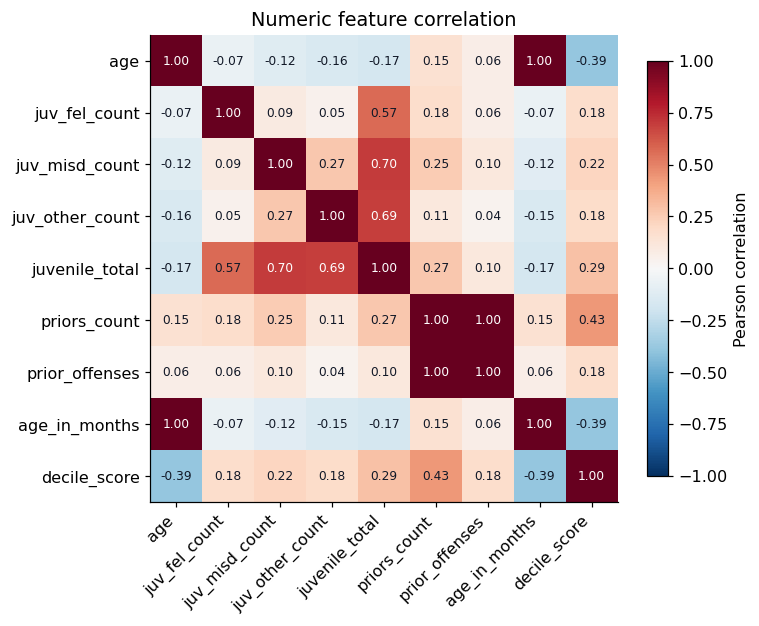

In [23]:
numeric_cols = ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "juvenile_total",
                 "priors_count", "prior_offenses", "age_in_months", "decile_score"]

corr_df = df_stage2[numeric_cols].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "#111827", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson correlation", shrink=0.8)
ax.set_title("Numeric feature correlation")
plt.tight_layout()
plt.show()

Two pairs jump out at r = 1.00: `prior_offenses` with `priors_count`, and `age_in_months` with `age`. Those are the easy catches - a plain correlation heatmap finds any *pairwise* duplicate on its own, no further tooling needed. **Drop `prior_offenses` and `age_in_months`** on the strength of this heatmap alone.

`juvenile_total` doesn't stand out here the same way, though - its correlation with any *single* other column is well under 1.0. That's the gap VIF is for: `juvenile_total` isn't a copy of one column, it's the *sum* of three (`juv_fel_count` + `juv_misd_count` + `juv_other_count`), a three-way relationship pairwise correlation can't see but a regression-based check can.

**VIF** (Variance Inflation Factor) measures how much the variance of an estimated regression coefficient is increased because of multicolinearity (correlation among predictor variables) in a regression model.
- VIF = 1: Predictor has no correlation with other variables.
- VIF < 5: Generally considered acceptable and low concern.
- VIF >5/10 : Indicates high colinearity.

In [24]:
vif_cols = ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "juvenile_total",
            "priors_count", "decile_score"]  # the two obvious pairwise dupes already dropped above

vif_data = df_stage2[vif_cols].apply(pd.to_numeric, errors="coerce").dropna()
vif_rows = []
with warnings.catch_warnings():
    # A "rank-deficient" warning here isn't a bug -- it's statsmodels telling us a column
    # is a perfect linear combination of the others, which is exactly what this check is for.
    warnings.simplefilter("ignore")
    for i, col in enumerate(vif_cols):
        try:
            vif = variance_inflation_factor(vif_data.values, i)
        except Exception:
            vif = float("inf")
        vif_rows.append({"column": col, "VIF": f"{vif:,.1f}" if np.isfinite(vif) and vif < 1e6 else "astronomical (perfectly redundant)"})
vif_table = pd.DataFrame(vif_rows).sort_values("column")
vif_table

,column,VIF
0,age,1.4
6,decile_score,1.7
1,juv_fel_count,astronomical (perfectly redundant)
2,juv_misd_count,astronomical (perfectly redundant)
3,juv_other_count,astronomical (perfectly redundant)
4,juvenile_total,astronomical (perfectly redundant)
5,priors_count,1.5


`age`, `priors_count`, and `decile_score` all sit near VIF ≈ 1 - unrelated to each other, nothing to fix. The four juvenile columns tell a completely different story: all four blow up together, because `juvenile_total` is an exact linear combination of the other three - the regression VIF is built on literally cannot be solved uniquely once you include it. **Verdict: drop `juvenile_total`** as well; `juv_fel_count`, `juv_misd_count`, and `juv_other_count` individually already carry everything it contains, without hiding *which* kind of prior offense drove the count.

Between the two checks: **drop `prior_offenses`, `age_in_months`, and `juvenile_total`** - the information all three carry survives in `priors_count`, `age`, and the three individual `juv_*_count` columns. The model would otherwise be handed the same information multiple times, which doesn't just waste a column - it makes coefficients and any importance-based feature selection unstable and hard to interpret.

`age_cat` (the coarse age bucket) isn't in the VIF table since it's categorical, but it's worth naming here too: it's a coarser view of the same information as `age`. It's kept for now - a decision-tree-style model can use a bucket boundary differently than a raw numeric split - but it's a candidate worth testing in this week's stretch goal (extend the encoder/scaler grid), or dropping later if it never adds anything a model with raw `age` alone can't already do.

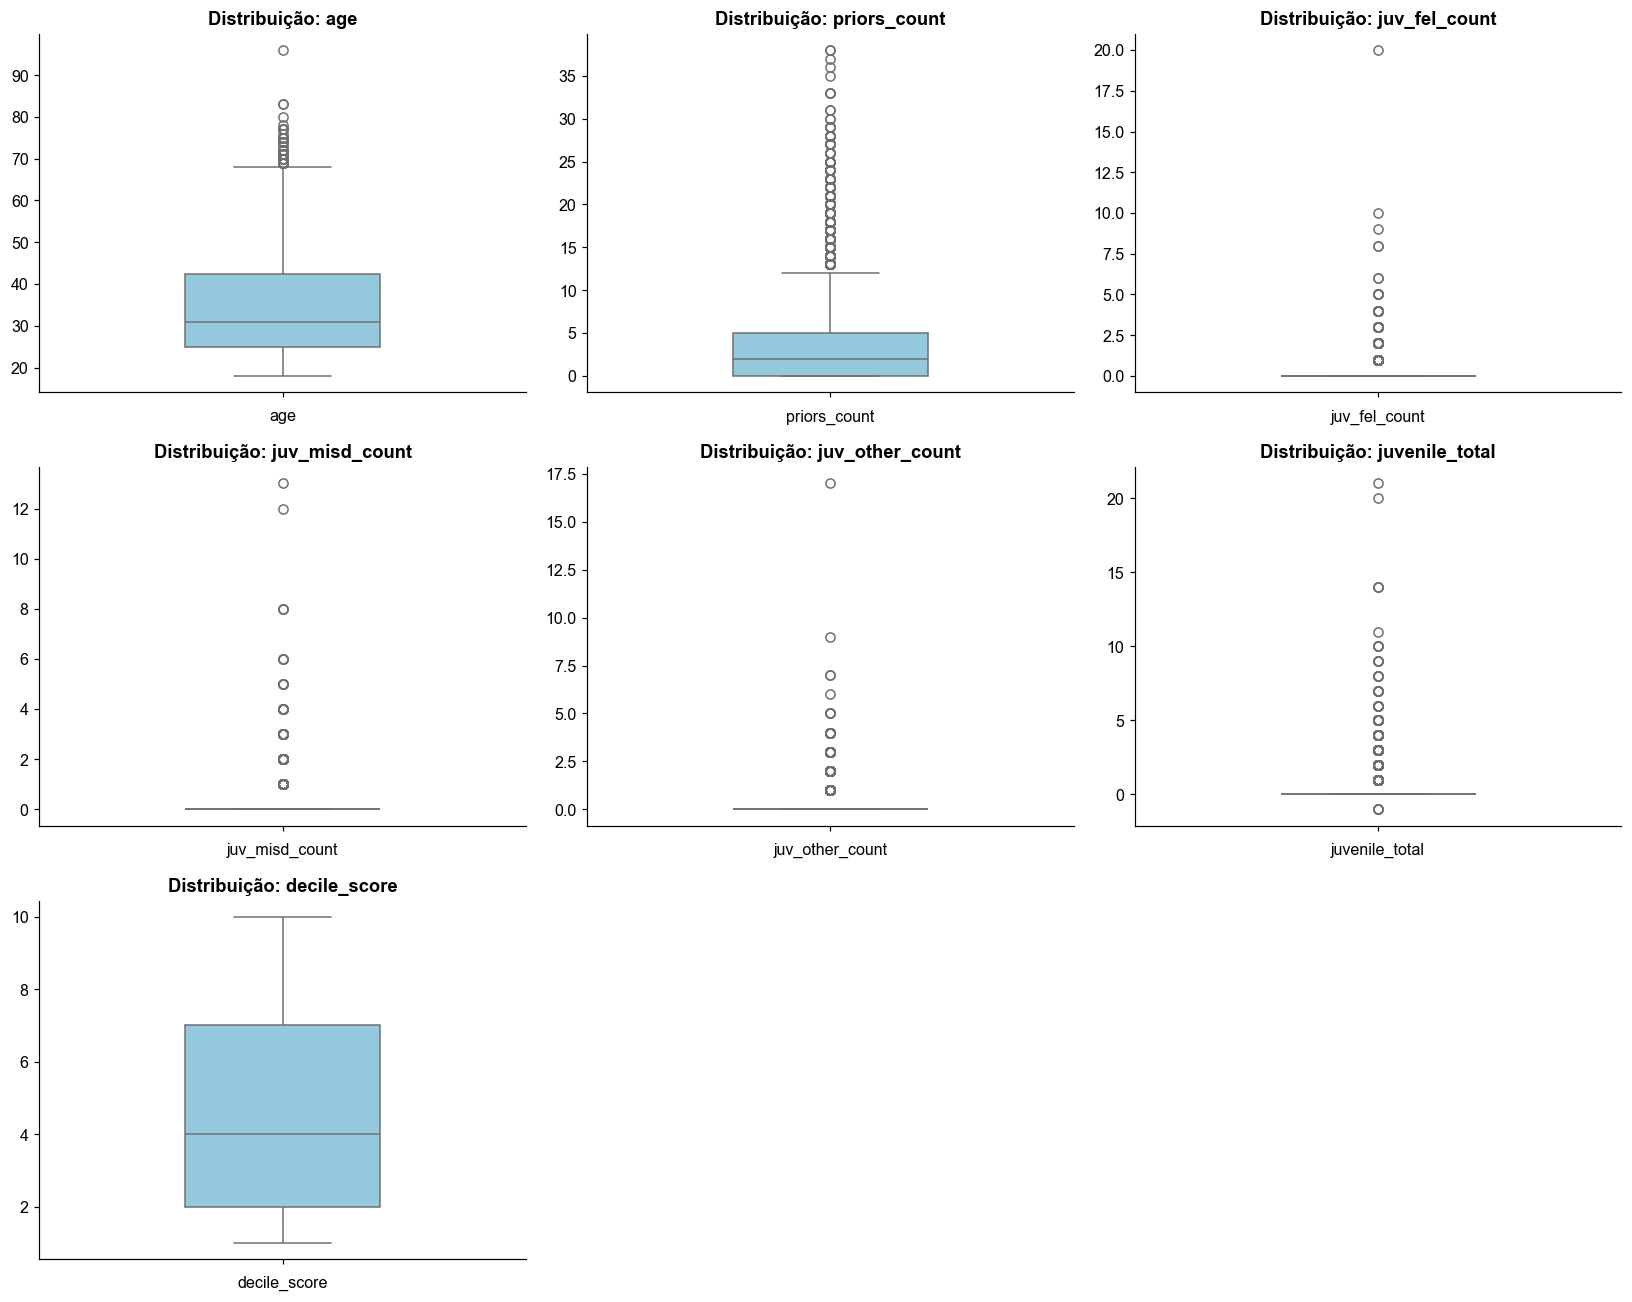

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir a lista de variáveis numéricas
num_cols = [
    'age', 
    'priors_count', 
    'juv_fel_count', 
    'juv_misd_count', 
    'juv_other_count', 
    'juvenile_total', 
    'decile_score'
]

# Configurar o tamanho da figura e a grelha de subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# Estilo visual
sns.set_theme(style="whitegrid")

# Gerar um boxplot para cada variável
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_stage2[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel(col)

# Esconder os eixos sobressalentes da grelha (já que são 7 variáveis numa grelha 3x3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

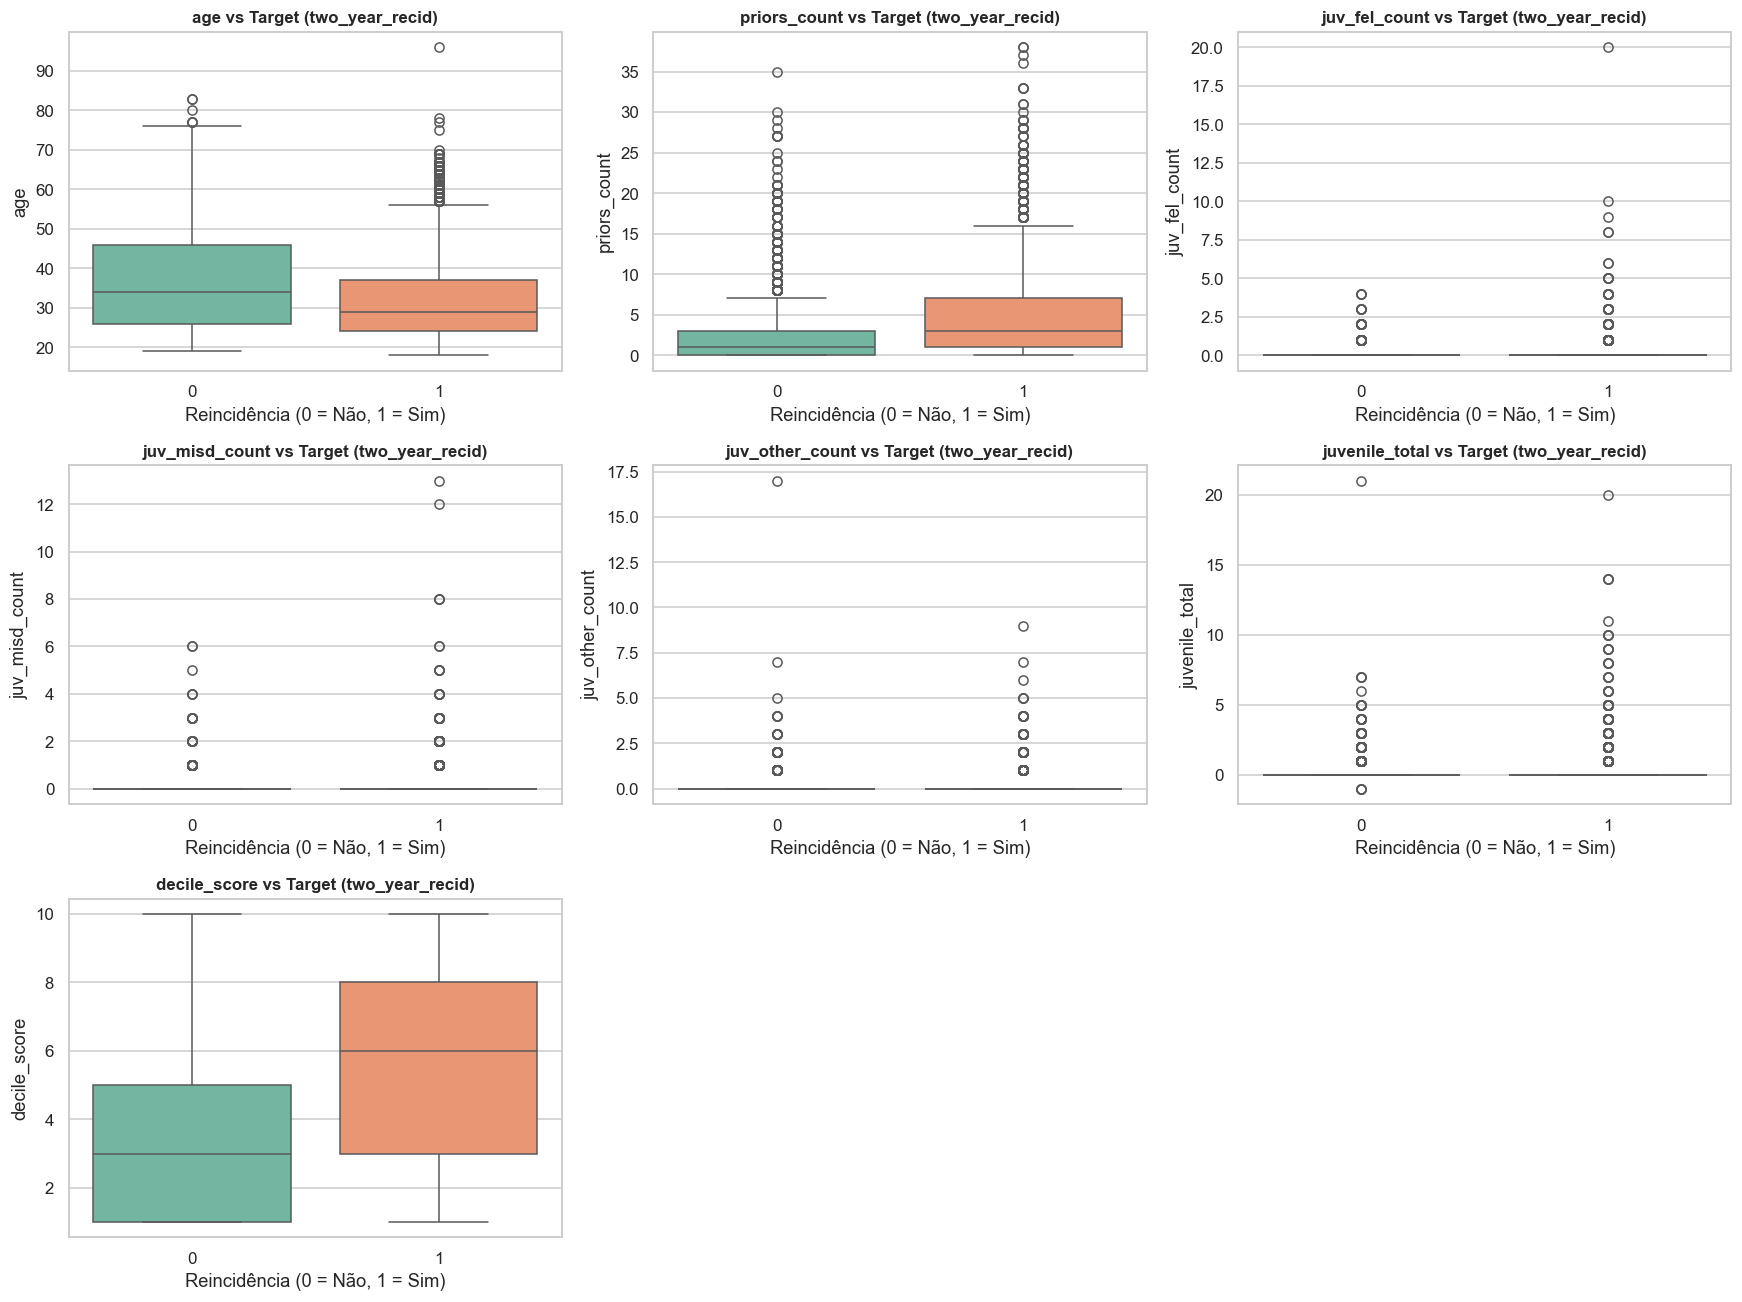

In [26]:
# Configurar a grelha para análise em relação ao Target
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df_stage2, 
        x='two_year_recid', 
        y=col, 
        ax=axes[i], 
        palette='Set2', 
        hue='two_year_recid',
        legend=False
    )
    axes[i].set_title(f'{col} vs Target (two_year_recid)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Reincidência (0 = Não, 1 = Sim)')
    axes[i].set_ylabel(col)

# Esconder os eixos sobressalentes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Key Insights: Numerical Variables Distribution & Target Analysis

* **Distribution & Outliers:** All numerical features present strongly right-skewed distributions with high outlier density, particularly the juvenile metrics (`juv_fel_count`, `juv_misd_count`, `juv_other_count`, `juvenile_total`), where the vast majority of cases record zero.
* **Age Dynamics:** Reoffending individuals (`two_year_recid` = 1) show a noticeably lower median age compared to non-reoffenders.
* **Prior Criminal History:** Individuals who recidivate present a substantially higher baseline and upper range of prior offenses (`priors_count`).
* **Risk Score Separation:** The `decile_score` exhibits strong predictive separation, with the reoffending group showing a median score of 6 versus 3 for the non-reoffending group.
* **Juvenile Offenses Impact:** While juvenile records are rare overall, higher counts and extreme values are almost exclusively concentrated in the reoffending group.

In [27]:
verdict_rows = [
    {"column": "age",             "issue": "missing (2.0%)",            "mechanism": "MCAR",  "action": "simple impute (median), no indicator needed"},
    {"column": "juv_fel_count",   "issue": "missing (3.0%)",            "mechanism": "MCAR",  "action": "simple impute (median), no indicator needed"},
    {"column": "priors_count",    "issue": "missing (~7%, incl. placeholders)", "mechanism": "MNAR", "action": "impute + `priors_count_was_missing` indicator"},
    {"column": "c_charge_degree", "issue": "missing (3.2%)",            "mechanism": "MNAR",  "action": "impute (mode) + `c_charge_degree_was_missing` indicator"},
    {"column": "race",            "issue": "missing (~1%, placeholders)", "mechanism": "MCAR", "action": "simple impute (mode), no indicator -- excluded from model features anyway"},
    {"column": "sex",             "issue": "missing (~1.5%, incl. placeholders)", "mechanism": "MCAR", "action": "simple impute (mode), no indicator needed"},
    {"column": "age",             "issue": "invalid values (age < 18 or > 100)", "mechanism": "domain rule", "action": "convert to NaN before imputation (already folded into the row above)"},
    {"column": "decile_score",    "issue": "invalid values (outside 1-10)", "mechanism": "domain rule", "action": "convert to NaN -- excluded from model features, but fix for the COMPAS-comparison metric"},
    {"column": "juv_fel_count",   "issue": "invalid values (negative)", "mechanism": "domain rule", "action": "convert to NaN before imputation (already folded into the row above)"},
    {"column": "priors_count",    "issue": "invalid values (>60 or placeholder token)", "mechanism": "domain rule", "action": "convert to NaN before imputation (already folded into the row above)"},
    {"column": "sex / race / c_charge_degree / score_text", "issue": "inconsistent category spelling", "mechanism": "data entry", "action": "canonicalize before anything else touches these columns"},
    {"column": "(whole row)",     "issue": "exact + id-repeated duplicates (72 rows)", "mechanism": "data entry", "action": "drop duplicates, keep first occurrence"},
    {"column": "prior_offenses",  "issue": "perfectly redundant with priors_count", "mechanism": "multicollinearity", "action": "drop column"},
    {"column": "age_in_months",   "issue": "deterministic function of age", "mechanism": "multicollinearity", "action": "drop column"},
    {"column": "juvenile_total",  "issue": "= sum of the 3 juv_*_count columns", "mechanism": "multicollinearity", "action": "drop column"},
]
verdict_table = pd.DataFrame(verdict_rows)
verdict_table

,column,issue,mechanism,action
0,age,missing (2.0%),MCAR,"simple impute (median), no indicator needed"
1,juv_fel_count,missing (3.0%),MCAR,"simple impute (median), no indicator needed"
2,priors_count,"missing (~7%, incl. placeholders)",MNAR,impute + `priors_count_was_missing` indicator
3,c_charge_degree,missing (3.2%),MNAR,impute (mode) + `c_charge_degree_was_missing` ...
4,race,"missing (~1%, placeholders)",MCAR,"simple impute (mode), no indicator -- excluded..."
5,sex,"missing (~1.5%, incl. placeholders)",MCAR,"simple impute (mode), no indicator needed"
6,age,invalid values (age < 18 or > 100),domain rule,convert to NaN before imputation (already fold...
7,decile_score,invalid values (outside 1-10),domain rule,convert to NaN -- excluded from model features...
8,juv_fel_count,invalid values (negative),domain rule,convert to NaN before imputation (already fold...
9,priors_count,invalid values (>60 or placeholder token),domain rule,convert to NaN before imputation (already fold...


In [30]:
# Hand this off to the Preprocessing notebook, and eventually to src/data_diagnostics.py /
# src/preprocessing.py, so the recipe is driven by this diagnosis rather than re-derived.
diagnosis_log = {
    "source_file": RAW_PATH,
    "n_rows_raw": int(len(df_raw)),
    "missingness_verdicts": {
        "age": "MCAR", "juv_fel_count": "MCAR", "priors_count": "MNAR",
        "c_charge_degree": "MNAR", "race": "MCAR", "sex": "MCAR",
    },
    "domain_rules": {
        "age": "18 <= age <= 100", "decile_score": "1 <= decile_score <= 10",
        "juv_fel_count": "juv_fel_count >= 0", "priors_count": "0 <= priors_count <= 60",
    },
    "placeholder_tokens": sorted(placeholder_tokens),
    "canonical_maps": CANONICAL_MAPS,
    "columns_to_drop": ["prior_offenses", "age_in_months", "juvenile_total", "id"],
    "duplicate_check": {"exact_row_duplicates": int(exact_dupe_count), "repeated_ids": int(id_dupe_count)},
}
with open("C:\\Users\\diogo\\Desktop\\NOVA IMS\\IA\\Labs\\ETAI-Pipeline\\data\\diagnosis_log.json", "w") as f:
    json.dump(diagnosis_log, f, indent=2)
print("Saved data/diagnosis_log.json")

Saved data/diagnosis_log.json
